In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [17]:
df=pd.read_csv('loan_data.csv')

In [18]:
df.shape

(1000, 10)

In [19]:
df.head()

,Unnamed: 0,salary,transaction_amount,loan_amount,credit_score,account_balance,monthly_expense,gender,city,account_type
0,0,54967.141530,366.602270,2472.682369,797.748603,96902.693967,13821.152514,Female,Pune,Savings
1,1,48617.356988,220.897635,374.125658,846.150255,96715.580176,1805.264339,Male,Bangalore,Savings
2,2,56476.885381,2023.568229,1143.180192,826.462290,88660.139388,4463.277054,Female,Pune,Current
3,3,65230.298564,2451.589879,4137.906434,768.565257,81889.035991,4061.174976,Male,Pune,Savings
4,4,47658.466253,64.191493,16224.506094,821.588541,98318.984971,2209.915232,Male,Mumbai,Business


## Data Cleaning

In [20]:
# Removed extra index numbers column.
df=df.drop(columns='Unnamed: 0')

In [21]:
df.head(2)

,salary,transaction_amount,loan_amount,credit_score,account_balance,monthly_expense,gender,city,account_type
0,54967.141530,366.602270,2472.682369,797.748603,96902.693967,13821.152514,Female,Pune,Savings
1,48617.356988,220.897635,374.125658,846.150255,96715.580176,1805.264339,Male,Bangalore,Savings


In [22]:
df.shape

(1000, 9)

In [23]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   salary              950 non-null    float64
 1   transaction_amount  950 non-null    float64
 2   loan_amount         950 non-null    float64
 3   credit_score        950 non-null    float64
 4   account_balance     950 non-null    float64
 5   monthly_expense     950 non-null    float64
 6   gender              950 non-null    object 
 7   city                950 non-null    object 
 8   account_type        950 non-null    object 
dtypes: float64(6), object(3)
memory usage: 70.4+ KB


In [24]:
# Removing extra decimals in numeric variables and keeping just two decimals
df=df.round(2)
df.head()

,salary,transaction_amount,loan_amount,credit_score,account_balance,monthly_expense,gender,city,account_type
0,54967.14,366.60,2472.68,797.75,96902.69,13821.15,Female,Pune,Savings
1,48617.36,220.90,374.13,846.15,96715.58,1805.26,Male,Bangalore,Savings
2,56476.89,2023.57,1143.18,826.46,88660.14,4463.28,Female,Pune,Current
3,65230.30,2451.59,4137.91,768.57,81889.04,4061.17,Male,Pune,Savings
4,47658.47,64.19,16224.51,821.59,98318.98,2209.92,Male,Mumbai,Business


In [25]:
# checking NUll values for each variable.
df.isna().sum()

salary                50
transaction_amount    50
loan_amount           50
credit_score          50
account_balance       50
monthly_expense       50
gender                50
city                  50
account_type          50
dtype: int64

In [26]:
# checking null values percentage for each variable.
df.isnull().mean()*100


salary                5.0
transaction_amount    5.0
loan_amount           5.0
credit_score          5.0
account_balance       5.0
monthly_expense       5.0
gender                5.0
city                  5.0
account_type          5.0
dtype: float64

for Fill values in null columns according to distribution
Distribution    Best Imputation	       Reason
Normal	        Mean	               Balanced data.
Any Skewed	    Median	               Robust to outliers.
Categorical	    Mode	               Most frequent category.

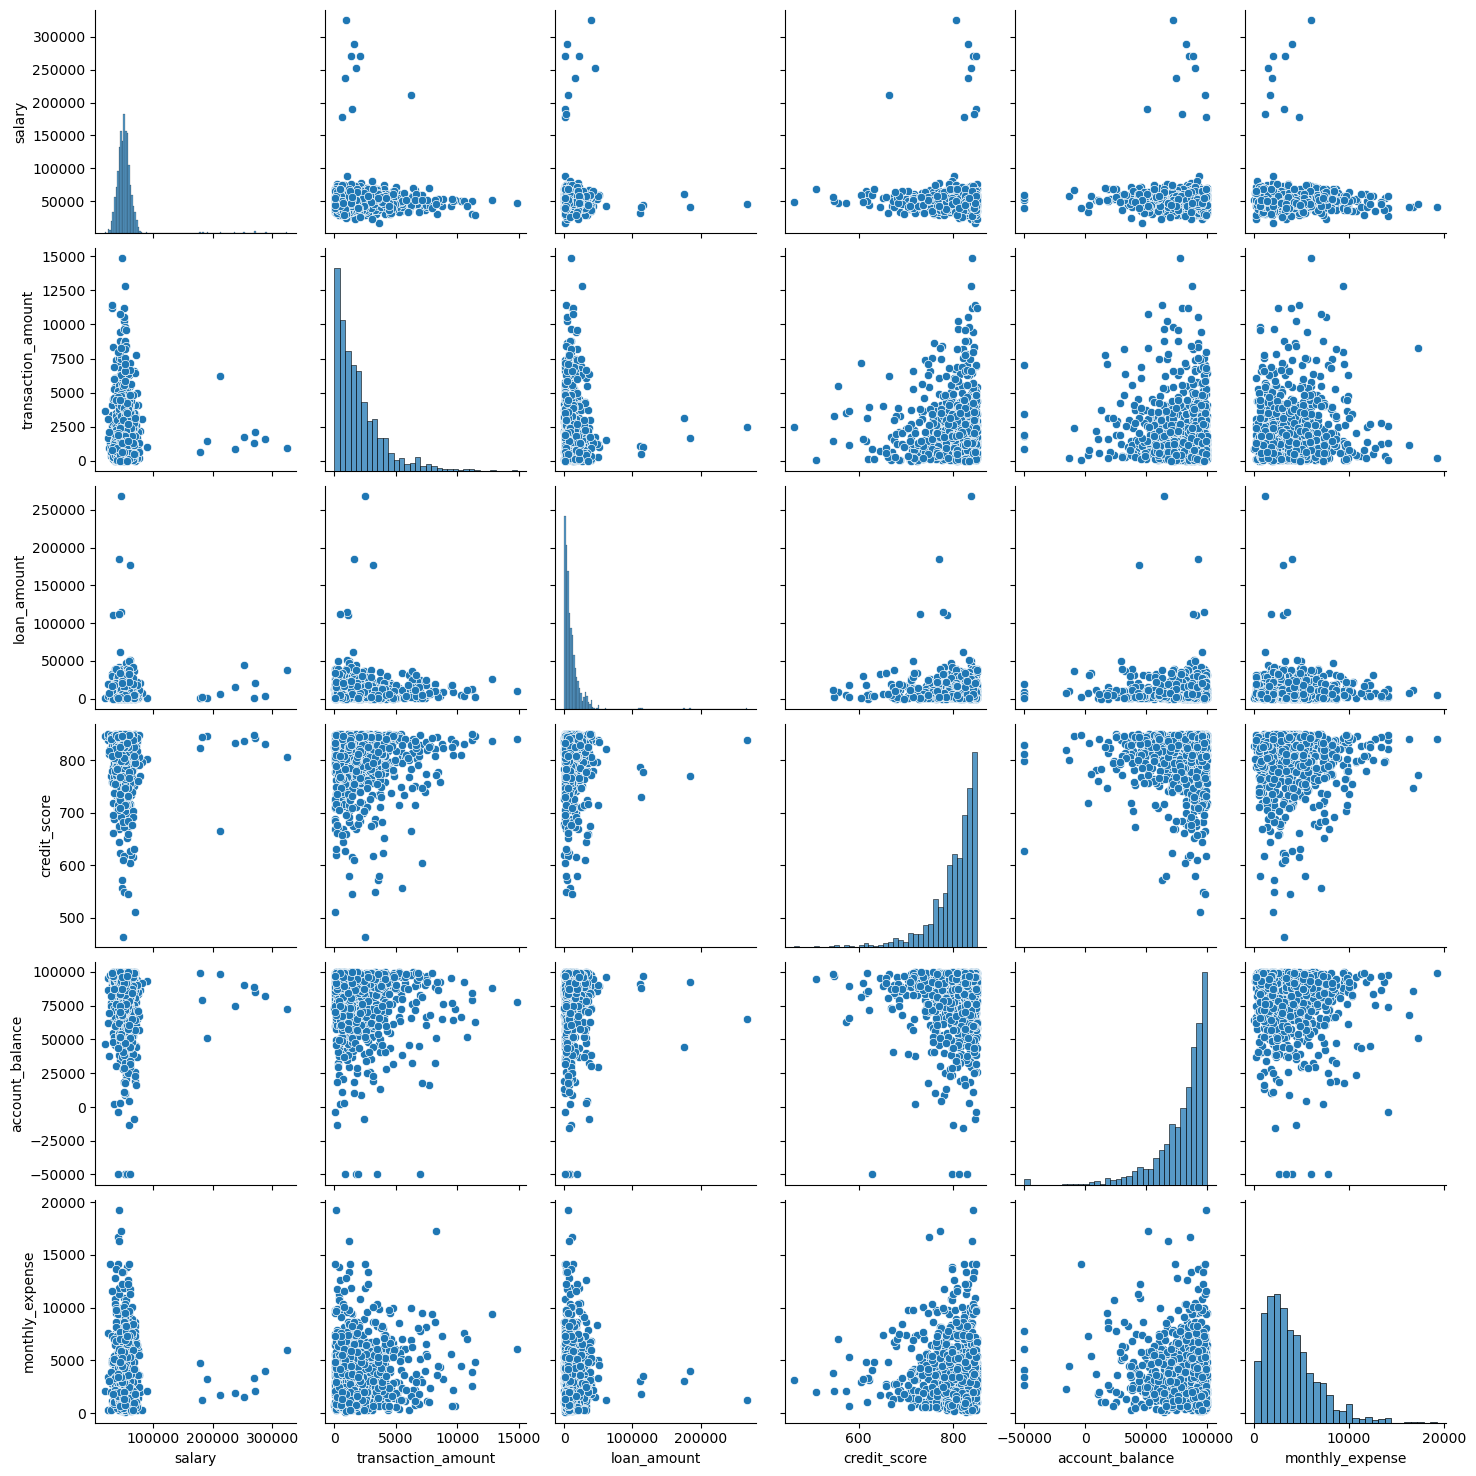

In [30]:
# Checking Distribution of Variables
sns.pairplot(df)
plt.show()

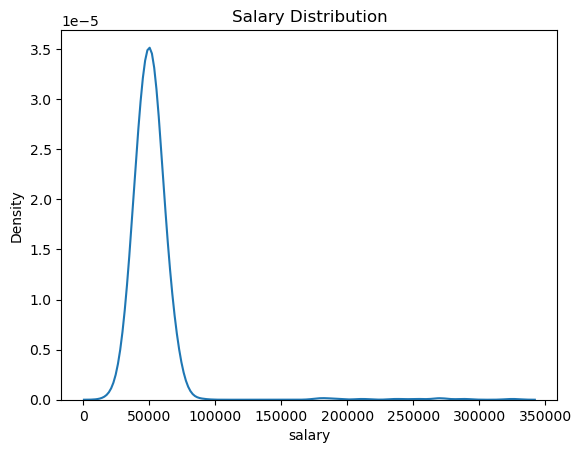

In [31]:
sns.kdeplot(data=df.salary)
plt.title('Salary Distribution')
plt.show()

In [33]:
df['salary'].skew()

np.float64(7.5538166319066855)

### Statistical Evidence (The Skewness Value)

### Skewness > 0: Right-skewed.

### Skewness = 0: Perfectly symmetrical (Normal Distribution).

### Skewness < 0: Left-skewed.


In [ ]:
# Salary column is Right Skewed  (postive skewed).

In [34]:
# filling median for NUll values.
df['salary']=df['salary'].fillna(df['salary'].median())
df['salary'].isna().sum()

np.int64(0)

In [35]:
# checking distribution of transaction_amount column.
df['transaction_amount'].skew()

np.float64(2.0119941251162254)

In [ ]:
# transaction_amount column is Right Skwed.

In [36]:
# filling median for NUll values.
df['transaction_amount']=df['transaction_amount'].fillna(df['transaction_amount'].median())
df['transaction_amount'].isna().sum()

np.int64(0)

In [37]:
# checking distribution of loan_amount column.
df['loan_amount'].skew()

np.float64(8.193680331657957)

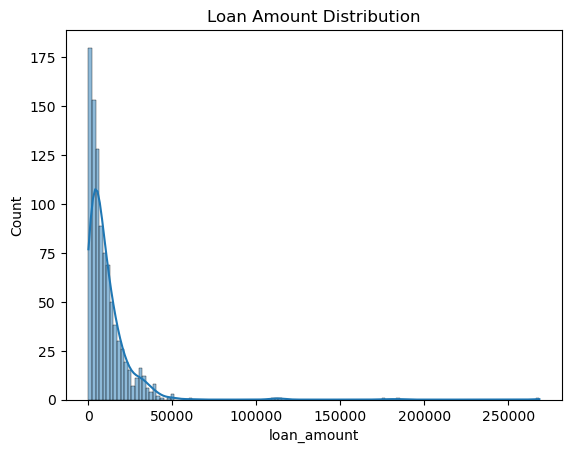

In [38]:
# checking visually distribution of loan amount
sns.histplot(data=df.loan_amount,kde=True)
plt.title('Loan Amount Distribution')
plt.show()

In [39]:
# filling median values for loan amount null values
df['loan_amount']=df['loan_amount'].fillna(df['loan_amount'].median())
df['loan_amount'].isna().sum()

np.int64(0)

In [40]:
#checking all variable null values
df.isna().sum()

salary                 0
transaction_amount     0
loan_amount            0
credit_score          50
account_balance       50
monthly_expense       50
gender                50
city                  50
account_type          50
dtype: int64

In [41]:
#checking distribution of credit score 
df['credit_score'].skew()

np.float64(-2.2599428081488497)

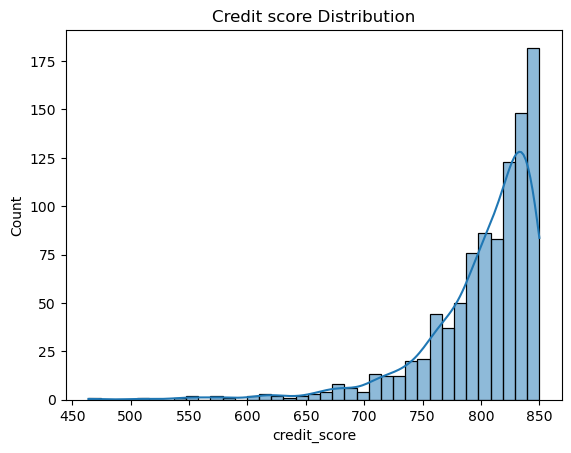

In [42]:
# checking visually credit score 
sns.histplot(data=df.credit_score,kde=True)
plt.title('Credit score Distribution')
plt.show()

In [ ]:
# credit score is left skewed

In [43]:
# filling median for credit score null values
df['credit_score']=df['credit_score'].fillna(df['credit_score'].median())
df.isna().sum()

salary                 0
transaction_amount     0
loan_amount            0
credit_score           0
account_balance       50
monthly_expense       50
gender                50
city                  50
account_type          50
dtype: int64

In [44]:
# checking Distribution for account balance and monthly expense variable
df[['account_balance','monthly_expense']].skew()

account_balance   -2.339443
monthly_expense    1.401746
dtype: float64

In [ ]:
# account balance is left skewed 
# monthly expense is right skewed

In [45]:
# filling median values for both variables
df[['account_balance','monthly_expense']]=df[['account_balance','monthly_expense']].fillna(df[['account_balance','monthly_expense']].median())
df.isna().sum()

salary                 0
transaction_amount     0
loan_amount            0
credit_score           0
account_balance        0
monthly_expense        0
gender                50
city                  50
account_type          50
dtype: int64

In [46]:
#checking null categorical columns
df[
    df[['gender','city','account_type']].isnull().any(axis=1) &
    df[['gender','city','account_type']].notnull().any(axis=1)
]


,salary,transaction_amount,loan_amount,credit_score,account_balance,monthly_expense,gender,city,account_type
10,45365.82,1448.065,911.210,826.70,87042.68,3298.08,Male,Delhi,NaN
11,45342.70,3236.230,9598.940,846.44,80109.92,4778.65,Female,NaN,Business
15,44377.12,4504.100,20732.410,796.54,43436.22,3298.08,NaN,Bangalore,Current
21,47742.24,2630.480,5018.260,849.73,99177.61,4243.22,Male,Delhi,NaN
25,51109.23,347.620,6720.995,846.56,45042.16,10861.41,Male,NaN,Business
...,...,...,...,...,...,...,...,...,...
958,55697.67,4223.580,4112.920,841.17,60250.41,3549.54,NaN,Delhi,Current
971,43189.48,2425.580,8225.230,846.83,87324.81,2009.67,NaN,Bangalore,Business
974,45538.17,1448.065,2920.550,797.68,95719.39,3399.31,NaN,Delhi,Savings
978,34160.97,6012.820,18086.070,803.96,87240.97,5143.81,Female,Mumbai,NaN


In [ ]:
# in gender, city and account type column NaN meaning is null values.

In [47]:
# Frequency Distribution for categorical variables.
print(df['gender'].value_counts())

print(df['city'].value_counts().sort_values(ascending=False))

print(df['account_type'].value_counts().sort_values(ascending=False))



gender
Male      503
Female    447
Name: count, dtype: int64
city
Mumbai       258
Delhi        241
Bangalore    239
Pune         212
Name: count, dtype: int64
account_type
Current     322
Savings     317
Business    311
Name: count, dtype: int64


In [48]:
df.isna().mean()*100

salary                0.0
transaction_amount    0.0
loan_amount           0.0
credit_score          0.0
account_balance       0.0
monthly_expense       0.0
gender                5.0
city                  5.0
account_type          5.0
dtype: float64

Since the data is balanced and missing values are low, mode imputation will not introduce bias and helps retain all rows. It is simple, efficient, and acceptable in real-world scenarios when data quality is already good.

Other Situations (If Conditions Change)
 If Missing Values are HIGH (>15–20%)

In such cases, using mode can distort the dataset.

Better approach:

df['city'].fillna('Unknown', inplace=True)

 This preserves missing information instead of forcing incorrect assumptions.

 If Data is IMBALANCED

Example: one category = 80%

 Avoid mode (it increases bias)

 Use:

"Unknown" category
Or group rare categories into "Others"

 If Data is Time-Based - we should Use forward/backward fill.

 and we can Use Model-based imputation also for null values Predict missing category using Machine learning.

In [49]:
# filling mode for categorical variable in our case. 
df[['gender','city','account_type']] = df[['gender','city','account_type']].fillna(
    df[['gender','city','account_type']].mode().iloc[0]
)
df.isna().sum()

salary                0
transaction_amount    0
loan_amount           0
credit_score          0
account_balance       0
monthly_expense       0
gender                0
city                  0
account_type          0
dtype: int64

In [50]:
df.head()

,salary,transaction_amount,loan_amount,credit_score,account_balance,monthly_expense,gender,city,account_type
0,54967.14,366.60,2472.68,797.75,96902.69,13821.15,Female,Pune,Savings
1,48617.36,220.90,374.13,846.15,96715.58,1805.26,Male,Bangalore,Savings
2,56476.89,2023.57,1143.18,826.46,88660.14,4463.28,Female,Pune,Current
3,65230.30,2451.59,4137.91,768.57,81889.04,4061.17,Male,Pune,Savings
4,47658.47,64.19,16224.51,821.59,98318.98,2209.92,Male,Mumbai,Business


In [51]:
df.isna().sum()

salary                0
transaction_amount    0
loan_amount           0
credit_score          0
account_balance       0
monthly_expense       0
gender                0
city                  0
account_type          0
dtype: int64

In [ ]:
# I have handel all null values, now I have to detect and treat outliers.

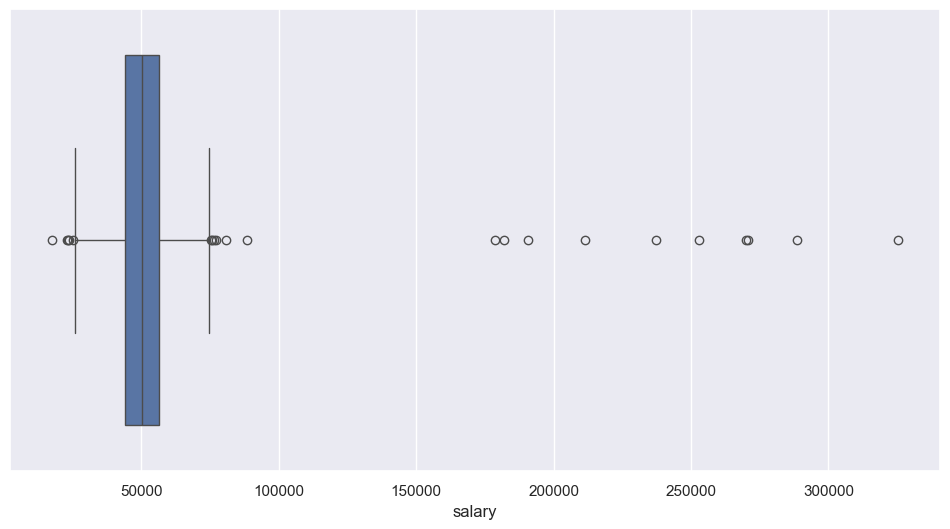

In [54]:
# checking Outliers
sns.set(rc={'figure.figsize':(12,6)})
sns.boxplot(data=df.salary,orient='h')
plt.show()

In [ ]:
# Salary column has outliers.

In [60]:
# IQR method for know outliers
Q1=df['salary'].quantile(0.25)
Q3=df['salary'].quantile(0.75)
IQR = Q3-Q1
lower = Q1-1.5*IQR
upper = Q3+1.5*IQR
print("salary calculation without outlier:", lower,upper)
df_no_outlier=df[(df['salary']>=lower)&(df['salary']<=upper)]
print(df_no_outlier)

salary calculation without outlier: 25559.197499999995 74890.9575
       salary  transaction_amount  loan_amount  credit_score  account_balance  \
0    54967.14              366.60     2472.680        797.75         96902.69   
1    48617.36              220.90      374.130        846.15         96715.58   
2    56476.89             2023.57     1143.180        826.46         88660.14   
3    65230.30             2451.59     4137.910        768.57         81889.04   
4    47658.47               64.19    16224.510        821.59         98318.98   
..        ...                 ...          ...           ...              ...   
995  47189.00              658.91    20984.240        845.87         95925.79   
996  67976.87              463.85     4933.210        808.28         99196.85   
997  56408.43             1453.71     6720.995        730.69         99558.22   
998  44288.21               11.04    34440.780        824.77         70212.57   
999  55725.83               15.39      688.

In [62]:
df_no_outlier.describe()

,salary,transaction_amount,loan_amount,credit_score,account_balance,monthly_expense
count,979.000000,979.000000,979.000000,979.000000,979.000000,979.000000
mean,50186.077896,1996.783739,10409.248064,802.086251,80200.332518,3917.350041
std,9109.511564,1984.381224,15592.699095,48.498382,21020.144068,2704.089286
min,25761.210000,6.450000,0.120000,463.820000,-50000.000000,60.600000
25%,44041.155000,596.565000,3140.955000,786.425000,73134.685000,2014.065000
50%,50404.180000,1448.065000,6720.995000,816.435000,86780.575000,3298.080000
75%,56183.040000,2643.740000,12928.740000,834.555000,94265.865000,5267.400000
max,74632.420000,14883.450000,268463.230000,850.000000,99995.460000,19260.470000


In [63]:
df['salary'].describe()

count      1000.000000
mean      52126.455950
std       21721.732464
min       17587.330000
25%       44058.607500
50%       50404.180000
75%       56391.547500
max      325199.650000
Name: salary, dtype: float64

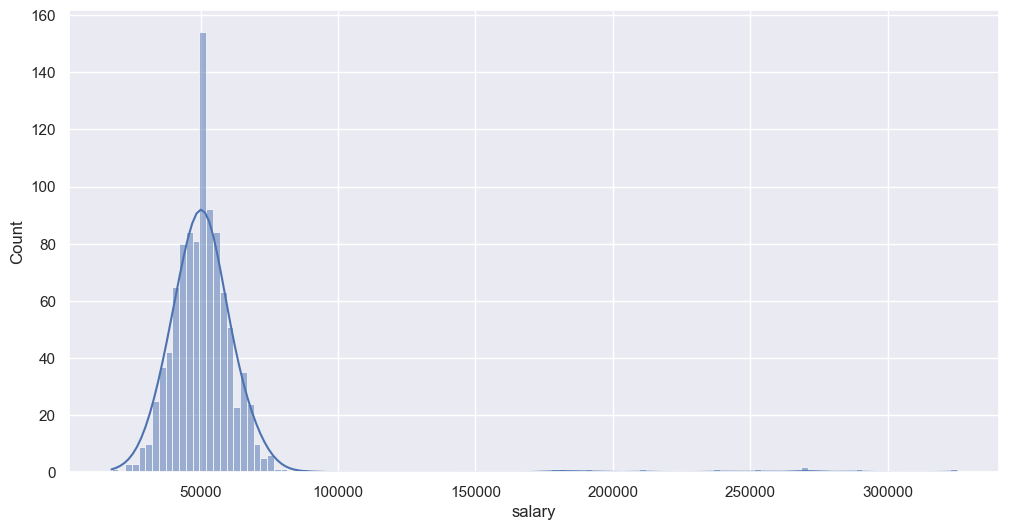

<Figure size 500x500 with 0 Axes>

In [69]:
sns.histplot(data=df.salary,kde=True)
plt.figure(figsize=(5,5))
plt.show()

In [66]:
df['salary'].skew()

np.float64(7.758104570541419)

In [70]:
# checking log transformation for outlier
df['salary_log']=np.log(df['salary'])
df['salary_log'].describe()

count    1000.000000
mean       10.820942
std         0.252260
min         9.774934
25%        10.693276
50%        10.827829
75%        10.940075
max        12.692195
Name: salary_log, dtype: float64

In [71]:
df['salary_log'].skew()

np.float64(2.042154476662483)

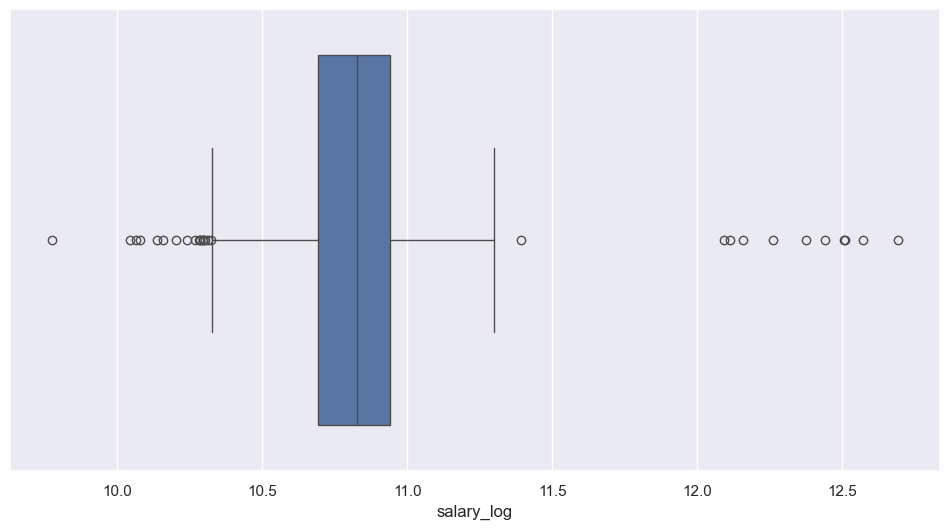

In [72]:
sns.boxplot(data=df.salary_log,orient='h')
plt.show()

In [ ]:
# used log transformation for salary but still outliers are there.

In [90]:
#  Capping method
lower1 = df['salary'].quantile(0.01)
upper1 = df['salary'].quantile(0.99)
salary_capped = np.clip(df['salary'],lower1,upper1)


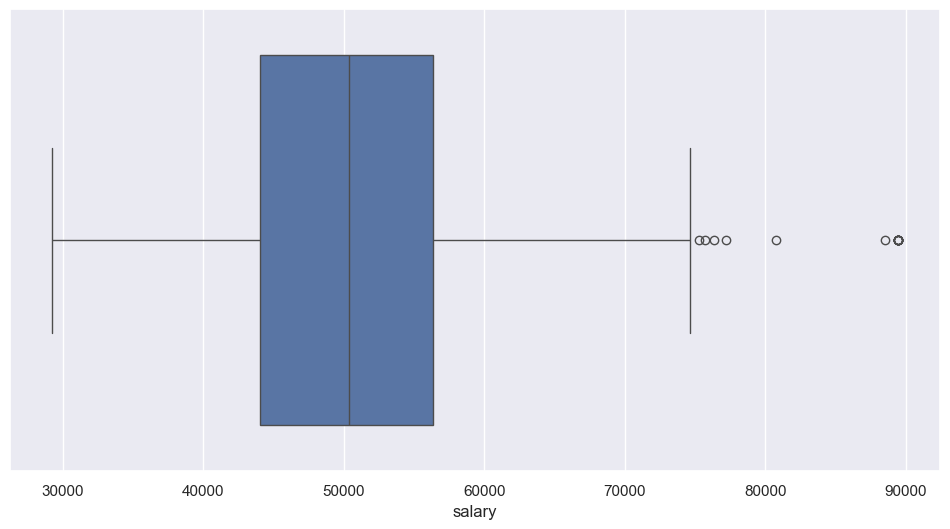

In [91]:
# checking outliers after capping method
sns.boxplot(data=salary_capped,orient='h')
plt.show()

In [85]:
df.head()

,salary,transaction_amount,loan_amount,credit_score,account_balance,monthly_expense,gender,city,account_type,salary_log
0,54967.14,366.60,2472.68,797.75,96902.69,13821.15,Female,Pune,Savings,10.914491
1,48617.36,220.90,374.13,846.15,96715.58,1805.26,Male,Bangalore,Savings,10.791736
2,56476.89,2023.57,1143.18,826.46,88660.14,4463.28,Female,Pune,Current,10.941587
3,65230.30,2451.59,4137.91,768.57,81889.04,4061.17,Male,Pune,Savings,11.085679
4,47658.47,64.19,16224.51,821.59,98318.98,2209.92,Male,Mumbai,Business,10.771816


In [92]:
print('original:',df['salary'].skew())
print("log transformation:",df['salary_log'].skew())
print("Capped:",salary_capped.skew())

original: 7.758104570541419
log transformation: 2.042154476662483
Capped: 0.612460476226491


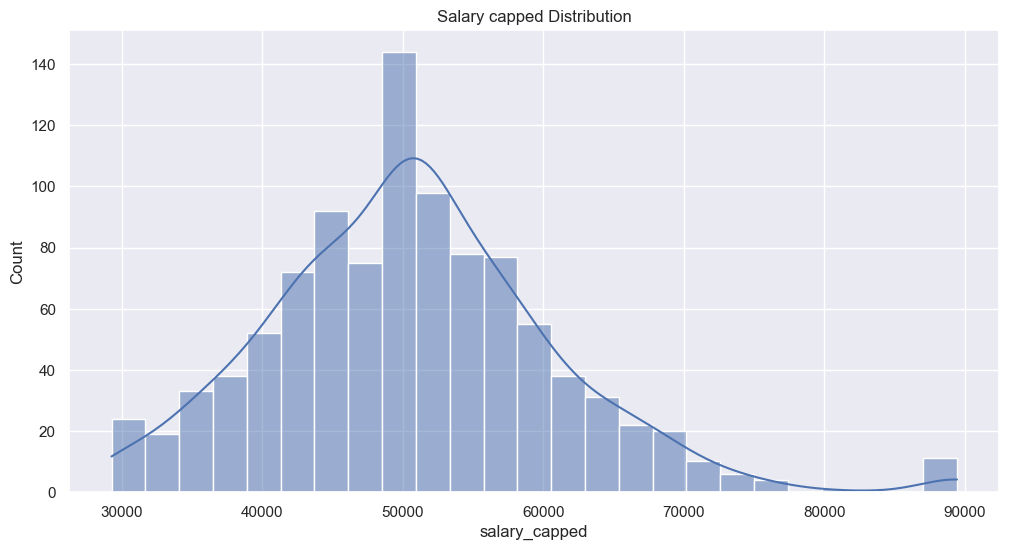

In [95]:
# checking distribution after treating outlier
sns.histplot(data=df.salary_capped,kde=True)
plt.title('Salary capped Distribution')
plt.show()

In [96]:
# salary capped variable has  symmetrical distribution now.

In [93]:
df.head(2)

,salary,transaction_amount,loan_amount,credit_score,account_balance,monthly_expense,gender,city,account_type,salary_log
0,54967.14,366.6,2472.68,797.75,96902.69,13821.15,Female,Pune,Savings,10.914491
1,48617.36,220.9,374.13,846.15,96715.58,1805.26,Male,Bangalore,Savings,10.791736


In [94]:
df['salary_capped']=df_capped_salary
df.head()

,salary,transaction_amount,loan_amount,credit_score,account_balance,monthly_expense,gender,city,account_type,salary_log,salary_capped
0,54967.14,366.60,2472.68,797.75,96902.69,13821.15,Female,Pune,Savings,10.914491,54967.14
1,48617.36,220.90,374.13,846.15,96715.58,1805.26,Male,Bangalore,Savings,10.791736,48617.36
2,56476.89,2023.57,1143.18,826.46,88660.14,4463.28,Female,Pune,Current,10.941587,56476.89
3,65230.30,2451.59,4137.91,768.57,81889.04,4061.17,Male,Pune,Savings,11.085679,65230.30
4,47658.47,64.19,16224.51,821.59,98318.98,2209.92,Male,Mumbai,Business,10.771816,47658.47


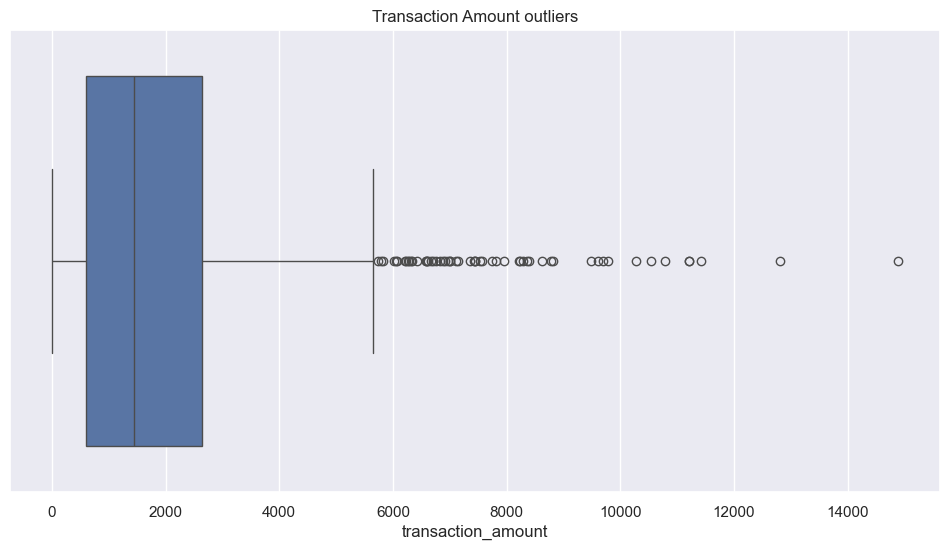

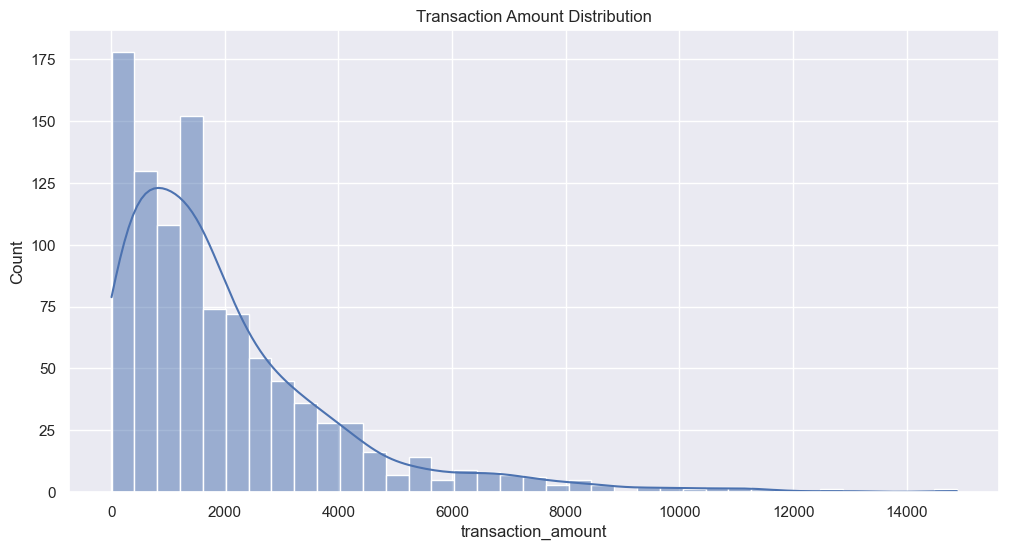

None


In [97]:
# cheking transaction_amount outlier and distribution
sns.boxplot(data=df.transaction_amount,orient='h')
plt.title("Transaction Amount outliers")
plt.show()

sns.histplot(data=df.transaction_amount, kde=True)
plt.title("Transaction Amount Distribution")
print(plt.show())



In [ ]:
# The transaction amount has outliers and is also right-skewed.

In [98]:
Q1 = df['transaction_amount'].quantile(0.25)
Q3 = df['transaction_amount'].quantile(0.75)

IQR_transaction=Q3-Q1

lower_transaction = Q1-1.5*IQR_transaction
upper_transaction = Q3-1.5*IQR_transaction

print(lower_transaction, upper_transaction)

-2456.4224999999997 -417.2024999999999


In [100]:
# log Transformation
df['log_transaction_amt']=np.log1p(df['transaction_amount'])

In [101]:
#skewed
print(df['transaction_amount'].skew())
print(df['log_transaction_amt'].skew())

2.094124161633132
-0.970564457798177


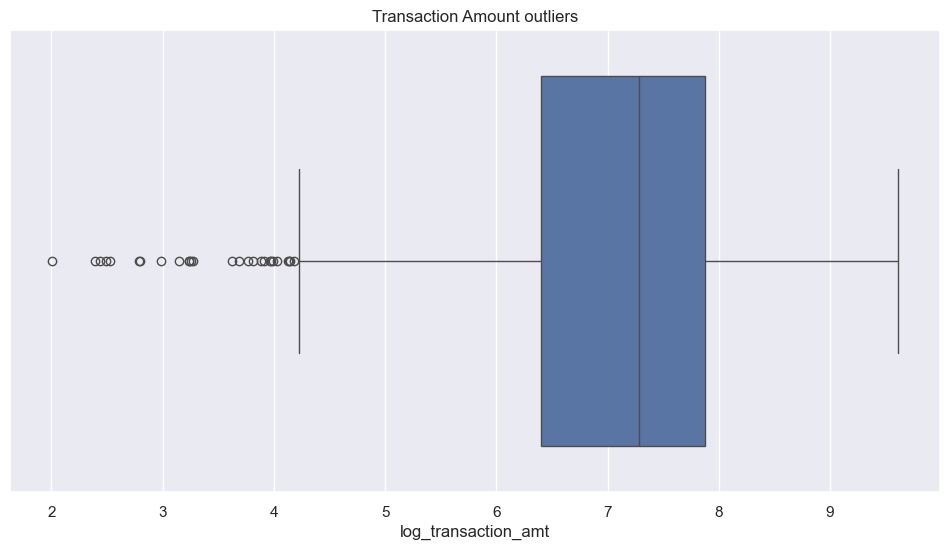

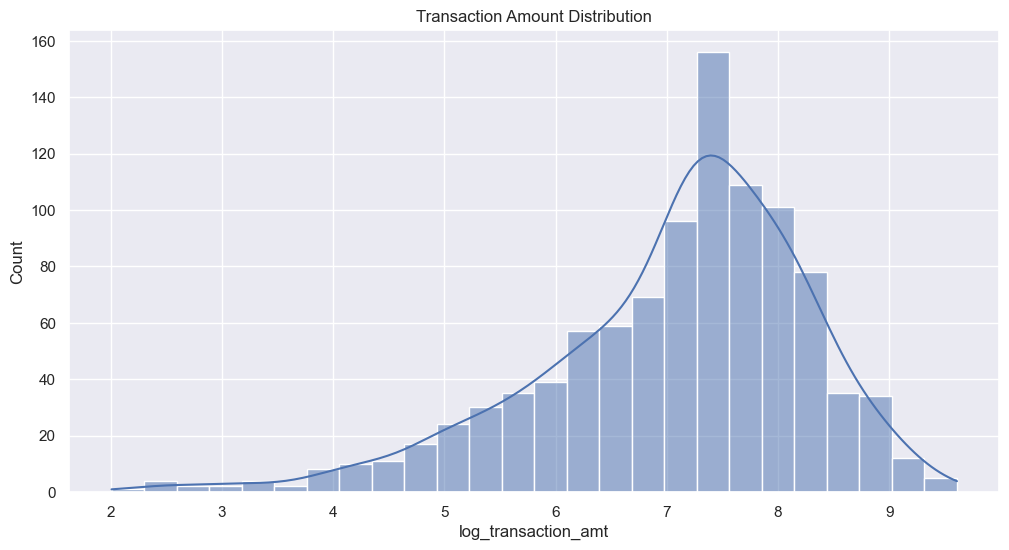

None


In [102]:
# cheking transaction_amount outlier and distribution
sns.boxplot(data=df.log_transaction_amt,orient='h')
plt.title("Transaction Amount outliers")
plt.show()

sns.histplot(data=df.log_transaction_amt, kde=True)
plt.title("Transaction Amount Distribution")
print(plt.show())


In [ ]:
# log transformation method is not helpfull in this case.

In [108]:
# applying capping method
lower_transaction_amt = df['transaction_amount'].quantile(0.01)
upper_transaction_amt = df['transaction_amount'].quantile(0.99)
df['transaction_amt_capping']=np.clip(df['transaction_amount'],lower_transaction_amt,upper_transaction_amt)


In [109]:
df.head(2)

,salary,transaction_amount,loan_amount,credit_score,account_balance,monthly_expense,gender,city,account_type,salary_log,salary_capped,log_transaction_amt,transaction_amt_capping
0,54967.14,366.6,2472.68,797.75,96902.69,13821.15,Female,Pune,Savings,10.914491,54967.14,5.906995,366.6
1,48617.36,220.9,374.13,846.15,96715.58,1805.26,Male,Bangalore,Savings,10.791736,48617.36,5.402227,220.9


In [110]:
# checking skew 
print("original:",df['transaction_amount'].skew())
print("log Transformation:",df['log_transaction_amt'].skew())
print("Capping:",df['transaction_amt_capping'].skew())

original: 2.094124161633132
log Transformation: -0.970564457798177
Capping: 1.770822755853892


In [115]:
# Step 1: Log transform
df['transaction_log'] = np.log1p(df['transaction_amount'])

# Step 2: Light capping (better version)
lower = df['transaction_log'].quantile(0.02)
upper = df['transaction_log'].quantile(0.98)

# Step 3: Final feature
df['transaction_final'] = np.clip(df['transaction_log'], lower, upper)

In [116]:
df['transaction_final'].skew()

np.float64(-0.7509215402041335)

In [117]:
df.head(2)

,salary,transaction_amount,loan_amount,credit_score,account_balance,monthly_expense,gender,city,account_type,salary_log,salary_capped,log_transaction_amt,transaction_amt_capping,transaction_log,transaction_final
0,54967.14,366.6,2472.68,797.75,96902.69,13821.15,Female,Pune,Savings,10.914491,54967.14,5.906995,366.6,5.906995,5.906995
1,48617.36,220.9,374.13,846.15,96715.58,1805.26,Male,Bangalore,Savings,10.791736,48617.36,5.402227,220.9,5.402227,5.402227


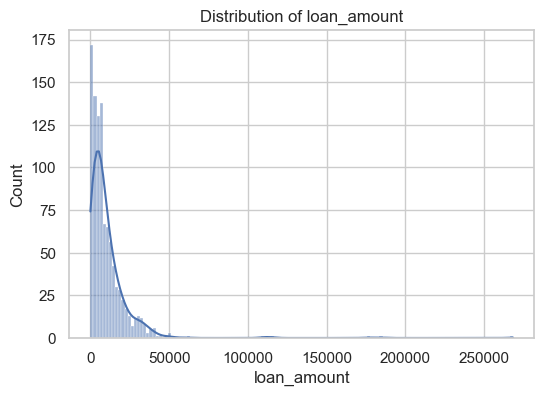

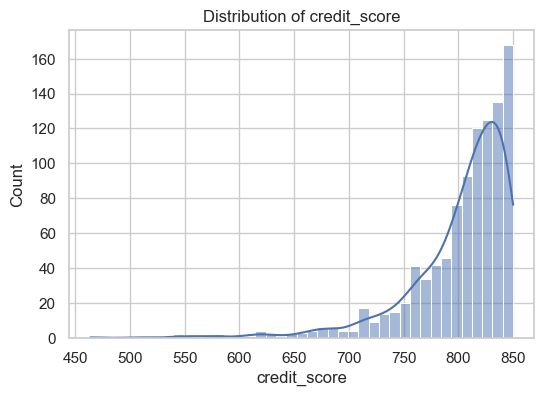

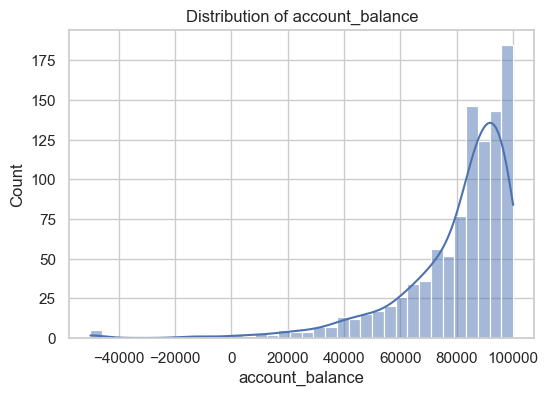

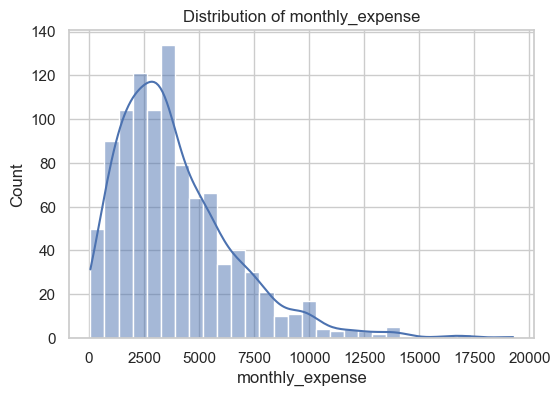

In [118]:
# List of numerical columns
num_cols = ['loan_amount', 'credit_score', 'account_balance', 'monthly_expense']

# Set style
sns.set(style="whitegrid")

# Loop through each column and plot distribution
for col in num_cols:
    plt.figure(figsize=(6,4))
    
    # Histogram + KDE curve
    sns.histplot(df[col], kde=True)
    
    # Title and labels
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Count')
    
    plt.show()

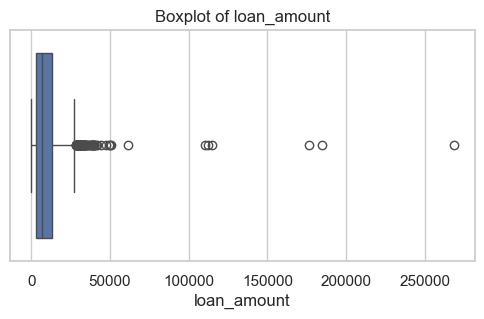

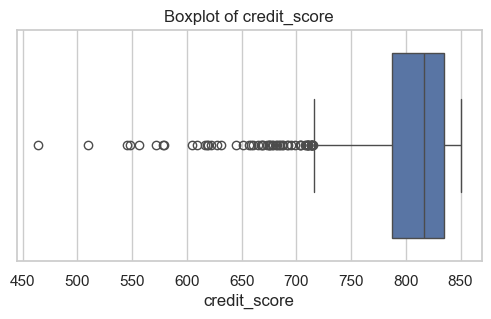

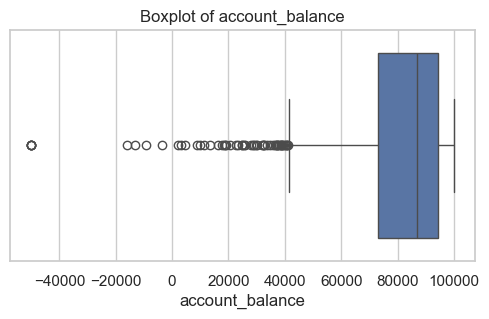

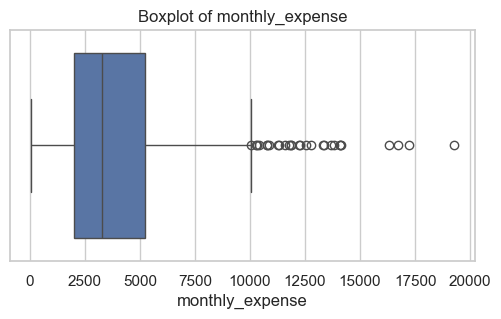

In [119]:
# Loop through each column and plot boxplot
for col in num_cols:
    plt.figure(figsize=(6,3))
    
    # Boxplot for outlier detection
    sns.boxplot(x=df[col])
    
    # Title
    plt.title(f'Boxplot of {col}')
    
    plt.show()

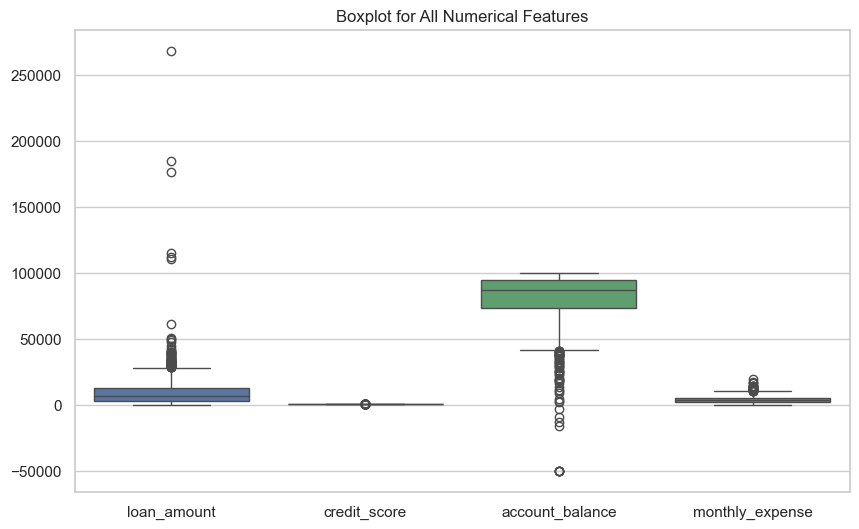

In [120]:
# Boxplot for all variables together
plt.figure(figsize=(10,6))
sns.boxplot(data=df[num_cols])
plt.title('Boxplot for All Numerical Features')
plt.show()

In [121]:
# Skewness of all numerical columns together
df[num_cols].skew()

loan_amount        8.405169
credit_score      -2.347521
account_balance   -2.429278
monthly_expense    1.467004
dtype: float64

In [122]:
# Log transform  for loan amount
df['loan_log'] = np.log1p(df['loan_amount'])

# Light capping
lower = df['loan_log'].quantile(0.02)
upper = df['loan_log'].quantile(0.98)

df['loan_final'] = np.clip(df['loan_log'], lower, upper)

In [123]:
df['loan_final'].skew()

np.float64(-0.9412888913231863)

In [125]:
# monthly expense log transformation
df['expense_final'] = np.log1p(df['monthly_expense'])
df['expense_final'].skew()

np.float64(-0.8028148035652877)

In [126]:
# credit score capping
lower = df['credit_score'].quantile(0.01)
upper = df['credit_score'].quantile(0.99)

df['credit_final'] = np.clip(df['credit_score'], lower, upper)

In [127]:
df['credit_final'].skew()

np.float64(-1.8333324361324443)

In [128]:
# account balance capping 
lower_amt_bal = df['account_balance'].quantile(0.01)
upper_amt_bal = df['account_balance'].quantile(0.99)

df['balance_final'] = np.clip(df['account_balance'], lower_amt_bal, upper_amt_bal)

In [129]:
print(df['loan_final'].skew())
print(df['expense_final'].skew())
print(df['credit_final'].skew())
print(df['balance_final'].skew())

-0.9412888913231863
-0.8028148035652877
-1.8333324361324443
-1.7608835330745098


In [130]:
# Log transform
df['loan_log'] = np.log1p(df['loan_amount'])

# Capping
loan_lower = df['loan_log'].quantile(0.02)
loan_upper = df['loan_log'].quantile(0.98)

# Final feature
df['loan_final'] = np.clip(df['loan_log'], loan_lower, loan_upper)

In [131]:
# Log transform
df['expense_log'] = np.log1p(df['monthly_expense'])

# Capping
exp_lower = df['expense_log'].quantile(0.02)
exp_upper = df['expense_log'].quantile(0.98)

# Final feature
df['expense_final'] = np.clip(df['expense_log'], exp_lower, exp_upper)

In [132]:
# Reverse
df['credit_rev'] = df['credit_score'].max() - df['credit_score']

# Log transform
df['credit_log'] = np.log1p(df['credit_rev'])

# Capping
credit_lower = df['credit_log'].quantile(0.02)
credit_upper = df['credit_log'].quantile(0.98)

# Final feature
df['credit_final'] = np.clip(df['credit_log'], credit_lower, credit_upper)

In [133]:
# Reverse
df['balance_rev'] = df['account_balance'].max() - df['account_balance']

# Log transform
df['balance_log'] = np.log1p(df['balance_rev'])

# Capping
bal_lower = df['balance_log'].quantile(0.02)
bal_upper = df['balance_log'].quantile(0.98)

# Final feature
df['balance_final'] = np.clip(df['balance_log'], bal_lower, bal_upper)

In [134]:
df[['loan_final', 'expense_final', 'credit_final', 'balance_final']].skew()

loan_final      -0.941289
expense_final   -0.636791
credit_final    -0.573508
balance_final   -0.661180
dtype: float64

In [135]:
df.columns

Index(['salary', 'transaction_amount', 'loan_amount', 'credit_score',
       'account_balance', 'monthly_expense', 'gender', 'city', 'account_type',
       'salary_log', 'salary_capped', 'log_transaction_amt',
       'transaction_amt_capping', 'transaction_log', 'transaction_final',
       'loan_log', 'loan_final', 'expense_final', 'credit_final',
       'balance_final', 'expense_log', 'credit_rev', 'credit_log',
       'balance_rev', 'balance_log'],
      dtype='object')

In [136]:
df.head()

,salary,transaction_amount,loan_amount,credit_score,account_balance,monthly_expense,gender,city,account_type,salary_log,...,loan_log,loan_final,expense_final,credit_final,balance_final,expense_log,credit_rev,credit_log,balance_rev,balance_log
0,54967.14,366.60,2472.68,797.75,96902.69,13821.15,Female,Pune,Savings,10.914491,...,7.813462,7.813462,9.331245,3.974998,8.037146,9.534028,52.25,3.974998,3092.77,8.037146
1,48617.36,220.90,374.13,846.15,96715.58,1805.26,Male,Bangalore,Savings,10.791736,...,5.927273,5.927273,7.499014,1.578979,8.095867,7.499014,3.85,1.578979,3279.88,8.095867
2,56476.89,2023.57,1143.18,826.46,88660.14,4463.28,Female,Pune,Current,10.941587,...,7.042444,7.042444,8.403863,3.200304,9.335767,8.403863,23.54,3.200304,11335.32,9.335767
3,65230.30,2451.59,4137.91,768.57,81889.04,4061.17,Male,Pune,Savings,11.085679,...,8.328188,8.328188,8.309473,4.411949,9.804077,8.309473,81.43,4.411949,18106.42,9.804077
4,47658.47,64.19,16224.51,821.59,98318.98,2209.92,Male,Mumbai,Business,10.771816,...,9.694340,9.694340,7.701164,3.381335,7.425048,7.701164,28.41,3.381335,1676.48,7.425048


In [137]:
df=df.drop(columns=['salary','transaction_amount','credit_score','account_balance','monthly_expense','loan_log','salary_log','expense_log','credit_log',
                    'balance_rev'])
df.head(2)

,loan_amount,gender,city,account_type,salary_capped,log_transaction_amt,transaction_amt_capping,transaction_log,transaction_final,loan_final,expense_final,credit_final,balance_final,credit_rev,balance_log
0,2472.68,Female,Pune,Savings,54967.14,5.906995,366.6,5.906995,5.906995,7.813462,9.331245,3.974998,8.037146,52.25,8.037146
1,374.13,Male,Bangalore,Savings,48617.36,5.402227,220.9,5.402227,5.402227,5.927273,7.499014,1.578979,8.095867,3.85,8.095867


In [138]:
df=df.drop(columns=['loan_amount','log_transaction_amt','transaction_amt_capping','credit_rev','balance_log'])
df.head(2)

,gender,city,account_type,salary_capped,transaction_log,transaction_final,loan_final,expense_final,credit_final,balance_final
0,Female,Pune,Savings,54967.14,5.906995,5.906995,7.813462,9.331245,3.974998,8.037146
1,Male,Bangalore,Savings,48617.36,5.402227,5.402227,5.927273,7.499014,1.578979,8.095867


In [145]:
df.sample(3)

,gender,city,account_type,salary_capped,transaction_final,loan_final,expense_final,credit_final,balance_final
965,Female,Delhi,Current,64401.17,7.519269,8.866412,8.937517,3.542842,10.463787
814,Female,Mumbai,Current,60318.45,5.718014,9.225574,8.762914,3.749504,11.158780
504,Male,Mumbai,Current,43493.57,8.743699,9.663441,9.205752,2.921547,7.878811


In [146]:
# Rename Columns (Remove _final)
df.rename(columns={
    'transaction_final': 'transaction',
    'loan_final': 'loan',
    'expense_final': 'expense',
    'credit_final': 'credit',
    'balance_final': 'balance'
}, inplace=True)

In [147]:
df.head()

,gender,city,account_type,salary_capped,transaction,loan,expense,credit,balance
0,Female,Pune,Savings,54967.14,5.906995,7.813462,9.331245,3.974998,8.037146
1,Male,Bangalore,Savings,48617.36,5.402227,5.927273,7.499014,1.578979,8.095867
2,Female,Pune,Current,56476.89,7.613113,7.042444,8.403863,3.200304,9.335767
3,Male,Pune,Savings,65230.30,7.804900,8.328188,8.309473,4.411949,9.804077
4,Male,Mumbai,Business,47658.47,4.177306,9.694340,7.701164,3.381335,7.425048
